# 서울시 집계구별 재무 특성 기반 신용대출 보유 여부 예측

신용카드 이용 패턴, 소득 구성(급여소득자/자영업자 비율) 등 재무 특성을 바탕으로 신용대출 보유 여부(다수 보유 집계구인지)를 예측하는 분류 모델을 만듭니다.

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd

df = pd.read_csv('C:/Users/micha/OneDrive/사진/바탕 화면/Lecture/Statistics Lecture/자료/Python/자료/소비활동지수를 위한 금융통계.csv', encoding='cp949')
# df = pd.read_csv('data/소비활동지수를_위한_금융통계.csv', encoding='cp949')
df.head()

,데이터기준년월(BS_YR_MON),서울시_블럭ID(BLK_CD),성별(GENDER),연령대(AGE),거주자_수(CUST_CNT),급여소득자_수(MDL4_CNT),자영업자_수(MDL5_CNT),"기타(무직,주부,학생등)수(MDL9_CNT)",평균_증빙_연소득(AVG_ICM1),평균_결정_연소득(AVG_ICM2),...,평균_체크카드_해외이용금액(3개월)(CHK_ABRD_M3_AMT),평균_보유주택건수(HOUS_HLD_CNT),자가거주자_수(ONHS_CNT),경형_승용차_보유자_수(CAR_SZ01_CNT),소형_승용차_보유자_수(CAR_SZ02_CNT),준중형_승용차_보유자_수(CAR_SZ03_CNT),중형_승용차_보유자_수(CAR_SZ04_CNT),대형_승용차_보유자_수(CAR_SZ05_CNT),국산_승용차_보유자_수(CAR_DMST_CNT),수입_승용차_보유자_수(CAR_FRGN_CNT)
0,201812,2*2*9*,2,5,16,1,5,1,NaN,37750,...,0,0,1,0,0,0,1,0,2,0
1,201903,2*3*7*,2,2,18,5,0,8,NaN,52554,...,10,0,0,0,0,1,0,0,0,0
2,201806,2*2*4*,1,5,14,11,0,2,NaN,13143,...,1,0,3,0,0,0,1,0,0,1
3,201906,6*5*9,1,1,8,12,2,6,NaN,41068,...,0,0,4,0,0,0,0,1,1,0
4,201803,3*3*4*,1,5,27,2,0,2,18025.0,21826,...,0,1,1,0,0,0,0,0,0,0


## 데이터 선택 및 타겟 재정의

원래는 '성별'을 타겟으로 시도했으나, 지표만으로는 성별이 잘 구분되지 않아, 비즈니스적으로 더 의미 있는 타겟으로 재구성했습니다.

**새 타겟**: `신용대출_보유자_수(CRDT_LN_CNT)`를 중앙값 기준으로 이진화한 `대출보유_상위50%` (해당 집계구의 신용대출 보유자 비중이 상대적으로 높은지 여부)

**데이터 누수 방지**: 타겟을 만드는 데 쓰인 `신용대출_보유자_수`와, 그와 직접 연동되는 `평균_신용대출_대출잔액`(보유자가 없으면 0에 가까워 사실상 타겟을 그대로 노출)은 피처에서 제외했습니다.

In [2]:
feature_cols = [
    '급여소득자_수(MDL4_CNT)',
    '자영업자_수(MDL5_CNT)',
    '기타(무직,주부,학생등)수(MDL9_CNT)',
    '주택담보대출_보유자_수(HOUS_LN_CNT)',
    '평균_주택담보대출_대출잔액(HOUS_LN_BAL)',
    '평균_신용카드_일시불이용금액(3개월)(SIN_FUL_M3_AMT)',
    '평균_신용카드_할부이용금액(3개월)(SIN_INSTL_M3_AMT)',
    '평균_신용카드_해외이용금액(3개월)(SIN_ABRD_M3_AMT)',
]
target_source_col = '신용대출_보유자_수(CRDT_LN_CNT)'

df_subset = df[feature_cols + [target_source_col]].copy()
df_subset.describe()

,급여소득자_수(MDL4_CNT),자영업자_수(MDL5_CNT),"기타(무직,주부,학생등)수(MDL9_CNT)",주택담보대출_보유자_수(HOUS_LN_CNT),평균_주택담보대출_대출잔액(HOUS_LN_BAL),평균_신용카드_일시불이용금액(3개월)(SIN_FUL_M3_AMT),평균_신용카드_할부이용금액(3개월)(SIN_INSTL_M3_AMT),평균_신용카드_해외이용금액(3개월)(SIN_ABRD_M3_AMT),신용대출_보유자_수(CRDT_LN_CNT)
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000,500.000000,500.000000,500.000000
mean,7.300000,1.694000,6.524000,1.530000,8.579985e+04,2422.360,630.982000,91.962000,3.282000
std,6.179188,2.186762,9.141146,2.058537,1.462031e+05,2571.369,802.344866,205.919115,5.411566
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,3.000000,0.000000,0.000000e+00,874.750,176.250000,0.000000,1.000000
50%,6.000000,1.000000,5.000000,1.000000,3.512250e+04,1808.500,447.000000,16.000000,2.000000
75%,10.000000,2.000000,8.000000,2.000000,1.274505e+05,3124.250,834.250000,87.000000,4.000000
max,39.000000,18.000000,184.000000,14.000000,1.550000e+06,21762.000,10611.000000,2001.000000,100.000000


In [3]:
print(df_subset.isnull().sum()) # 확인 결과 결측치는 없음

급여소득자_수(MDL4_CNT)                        0
자영업자_수(MDL5_CNT)                         0
기타(무직,주부,학생등)수(MDL9_CNT)                 0
주택담보대출_보유자_수(HOUS_LN_CNT)                0
평균_주택담보대출_대출잔액(HOUS_LN_BAL)              0
평균_신용카드_일시불이용금액(3개월)(SIN_FUL_M3_AMT)     0
평균_신용카드_할부이용금액(3개월)(SIN_INSTL_M3_AMT)    0
평균_신용카드_해외이용금액(3개월)(SIN_ABRD_M3_AMT)     0
신용대출_보유자_수(CRDT_LN_CNT)                  0
dtype: int64


In [4]:
# 상위 50% 기준 이진 타겟 생성 (해당 집계구의 신용대출 보유자 수가 50%보다 높은지)
median_val = df_subset[target_source_col].median()
df_subset['대출보유_상위50%'] = (df_subset[target_source_col] > median_val).astype(int)
print(df_subset['대출보유_상위50%'].value_counts())

대출보유_상위50%
0    268
1    232
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X = df_subset[feature_cols]
Y = df_subset['대출보유_상위50%']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train, Y_train, test_size=0.1, stratify=Y_train, random_state=42)

print(X_train.shape, X_test.shape)

(360, 8) (100, 8)


## 모델 학습 및 비교

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    pred = model.fit(X_train, Y_train).predict(X_val)
    acc = accuracy_score(Y_val, pred)
    results[name] = acc
    print(f'[{name}] 정확도: {acc:.3f}\n{classification_report(Y_val, pred)}\n')

[DecisionTree] 정확도: 0.575
              precision    recall  f1-score   support

           0       0.59      0.62      0.60        21
           1       0.56      0.53      0.54        19

    accuracy                           0.57        40
   macro avg       0.57      0.57      0.57        40
weighted avg       0.57      0.57      0.57        40


[RandomForest] 정확도: 0.550
              precision    recall  f1-score   support

           0       0.55      0.81      0.65        21
           1       0.56      0.26      0.36        19

    accuracy                           0.55        40
   macro avg       0.55      0.54      0.51        40
weighted avg       0.55      0.55      0.51        40


[XGBoost] 정확도: 0.500
              precision    recall  f1-score   support

           0       0.52      0.71      0.60        21
           1       0.45      0.26      0.33        19

    accuracy                           0.50        40
   macro avg       0.49      0.49      0.47        40

### 하이퍼파라미터 튜닝 (Dicision Tree)

In [7]:
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# 1. DecisionTree 탐색할 하이퍼파라미터 공간 정의

params = {'min_impurity_decrease': uniform(0.001, 0.001),
         'max_depth': randint(20, 50),
         'min_samples_split': randint(2, 25),
         'min_samples_leaf': randint(1, 25),
         }

# 2. RandomizedSearchCV 설정 (Validation을 위해 cv=5 적용)
gs = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    n_iter=100,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
)

# 3. Train 데이터로 튜닝 수행
gs.fit(X_train, Y_train)

# 4. 최적 파라미터 출력
print('[DecisionTree 최적 하이퍼파라미터]')
print(gs.best_params_)

# 5. Validation 데이터로 튜닝된 성능 최종 확인
best_gs = gs.best_estimator_
val_pred_gs = best_gs.predict(X_val)

print('\n[Validation Set 성능]')
print(f'Validation Accuracy: {accuracy_score(Y_val, val_pred_gs):.3f}')
print(classification_report(Y_val, val_pred_gs))

[DecisionTree 최적 하이퍼파라미터]
{'max_depth': 40, 'min_impurity_decrease': np.float64(0.0019699098521619943), 'min_samples_leaf': 12, 'min_samples_split': 7}

[Validation Set 성능]
Validation Accuracy: 0.475
              precision    recall  f1-score   support

           0       0.50      0.71      0.59        21
           1       0.40      0.21      0.28        19

    accuracy                           0.47        40
   macro avg       0.45      0.46      0.43        40
weighted avg       0.45      0.47      0.44        40



### 하이퍼파라미터 튜닝 (XGBoost)

In [8]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_params = {
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'n_estimators': randint(100, 300),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

xgb_gs = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params,
    n_iter=50,
    scoring='f1',       # 클래스 불균형이 있으니 f1 스코어 기준이 유리합니다!
    cv=3,
    n_jobs=-1,
    random_state=42
)

xgb_gs.fit(X_train, Y_train)
print("XGBoost 최적 파라미터:", xgb_gs.best_params_)

best_xgb_gs = xgb_gs.best_estimator_
val_pred_xgb_gs = best_xgb_gs.predict(X_val)

print('\n[Validation Set 성능]')
print(f'Validation Accuracy: {accuracy_score(Y_val, val_pred_xgb_gs):.3f}')
print(classification_report(Y_val, val_pred_xgb_gs))

XGBoost 최적 파라미터: {'colsample_bytree': np.float64(0.6298202574719083), 'learning_rate': np.float64(0.20737738732010347), 'max_depth': 3, 'n_estimators': 235, 'subsample': np.float64(0.602208846849441)}

[Validation Set 성능]
Validation Accuracy: 0.525
              precision    recall  f1-score   support

           0       0.54      0.67      0.60        21
           1       0.50      0.37      0.42        19

    accuracy                           0.53        40
   macro avg       0.52      0.52      0.51        40
weighted avg       0.52      0.53      0.51        40



### 예측 결과 확인 (실제값 vs 예측값)

In [9]:
result_df = X_test.copy()
result_df['실제값'] = Y_test.values
result_df['예측값'] = best_xgb_gs.predict(X_test)
result_df['정답여부'] = result_df['실제값'] == result_df['예측값']

print("예측 결과 샘플:")
print(result_df.head(10))

print("\n틀린 케이스:")
print(result_df[result_df['정답여부'] == False].head(5))

예측 결과 샘플:
     급여소득자_수(MDL4_CNT)  자영업자_수(MDL5_CNT)  기타(무직,주부,학생등)수(MDL9_CNT)  \
322                  3                 0                        10   
351                  9                 1                         3   
482                  5                 0                         4   
250                 14                 0                         9   
430                  0                 1                         6   
258                  2                 2                         9   
173                  6                 1                        15   
99                  24                 2                         6   
355                  9                10                         2   
238                 19                 0                        11   

     주택담보대출_보유자_수(HOUS_LN_CNT)  평균_주택담보대출_대출잔액(HOUS_LN_BAL)  \
322                          1                            0   
351                          0                            0   
482                          1

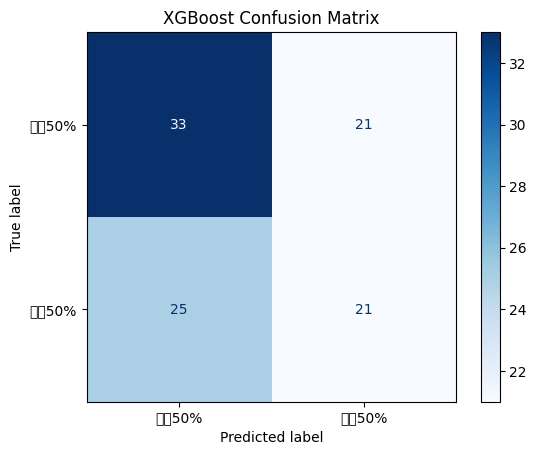

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(Y_test, best_xgb_gs.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['하위50%', '상위50%'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [11]:
# 변수 중요도
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_xgb_gs.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

                                 feature  importance
0                      급여소득자_수(MDL4_CNT)    0.131296
6  평균_신용카드_할부이용금액(3개월)(SIN_INSTL_M3_AMT)    0.126116
4            평균_주택담보대출_대출잔액(HOUS_LN_BAL)    0.125742
3              주택담보대출_보유자_수(HOUS_LN_CNT)    0.124255
5   평균_신용카드_일시불이용금액(3개월)(SIN_FUL_M3_AMT)    0.124169
7   평균_신용카드_해외이용금액(3개월)(SIN_ABRD_M3_AMT)    0.123316
1                       자영업자_수(MDL5_CNT)    0.122841
2               기타(무직,주부,학생등)수(MDL9_CNT)    0.122264


In [13]:
from sklearn.metrics import roc_auc_score

proba = best_xgb_gs.predict_proba(X_test)[:, 1]
print("Test AUC:", roc_auc_score(Y_test, proba))

Test AUC: 0.5434782608695652


In [14]:
# 최종 선택된 XGBoost 모델(best_xgb_gs)로 테스트 데이터(Test Set) 최종 평가
final_pred = best_xgb_gs.predict(X_test)

print("[최종 Test Set 평가 결과 - XGBoost]")
print(classification_report(Y_test, final_pred))

[최종 Test Set 평가 결과 - XGBoost]
              precision    recall  f1-score   support

           0       0.57      0.61      0.59        54
           1       0.50      0.46      0.48        46

    accuracy                           0.54       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.54      0.54      0.54       100



## 결론 및 한계

**진행 과정 요약**
- 처음에는 '성별'을 타겟으로 예측을 시도했으나, 정확도가 55~58%로 랜덤 수준(50%)과 큰 차이가 없어 재무 데이터만으로는 성별이 잘 구분되지 않는다는 것을 확인했습니다.
- 이를 바탕으로, 데이터가 실제로 담고 있는 신용/대출 관련 정보를 활용하는 쪽으로 타겟을 '신용대출 보유자 비중'으로 재정의했습니다.

**주요 발견**
- 변수 중요도 상위 항목은 급여소득자 수, 기타(무직·주부·학생 등) 수, 
  신용카드 일시불 이용액 순으로 나타났으나, 항목 간 중요도 차이는 크지 않았습니다.
- 최종 테스트 세트 성능은 accuracy 0.53, f1-score 약 0.49~0.56 수준으로,
  두 클래스가 균형(54:46)을 이루도록 타겟을 재정의했음에도 랜덤 수준(50%)을 
  크게 벗어나지 못했습니다. 이는 주어진 8개 재무 피처만으로는 신용대출 보유 
  비중(상위/하위 50%)을 안정적으로 구분하기 어렵다는 것을 시사합니다.
- 최종 모델의 Test AUC는 0.49로, 완전 무작위 수준(0.5)과 사실상 동일했습니다.
  이는 accuracy(0.53)가 baseline(다수 클래스 비율, 0.54)과 비슷했던 것과
  일치하는 결과로, 급여소득자 수·자영업자 수·신용카드 이용 패턴 등 
  현재 확보한 8개 재무 피처만으로는 집계구의 신용대출 보유 비중
  (상위/하위 50%)을 구분할 수 있는 정보가 담겨 있지 않다는 것을 
  통계적으로 확인했습니다.

**한계**
- 집계구 단위로 집계된 데이터라 개인 단위 신용 이력, 신용점수, 
  기존 부채 상태 등 실제 대출 심사에 쓰이는 핵심 정보가 빠져 있어,
  간접적인 소비/소득 패턴만으로는 예측이 어려웠을 가능성이 큽니다.
- 표본 수(500개)의 한계보다는, AUC가 0.5에 근접한 것으로 볼 때
  '표본 부족'보다는 '피처 자체의 정보 부족'이 더 근본적인 원인으로 보입니다.
- Validation set이 40개로 작아, 모델 간 성능 비교(Decision Tree/RandomForest/
  XGBoost) 결과의 변동폭이 컸을 가능성이 있습니다.

**배운 점**
- 타겟 변수 선택이 모델 성능과 프로젝트의 설득력에 미치는 영향이 크다는 것을 확인했습니다. 단순히 예측 가능한 변수를 고르기보다, 데이터가 실제로 담고 있는 정보와 비즈니스 맥락에 맞는 타겟을 고르는 것이 중요하다는 것을 배웠습니다.